/tmp/ipykernel_2555/1664699274.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_m

Dropped 0.4% entries from factor data: 0.4% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.197751,222.694824,26.847087,21.124308,18074,20.159051
2,12.417096,270.402985,50.068128,35.776840,17852,19.911440
3,16.396914,315.419159,71.164841,46.131524,17884,19.947132
4,21.820440,449.636810,96.029779,55.427423,17852,19.911440
5,29.440641,989.272705,153.728398,84.665670,17995,20.070937


Returns Analysis


,1D,5D,10D
Ann. alpha,0.411,0.310,0.211
beta,0.007,0.018,0.018
Mean Period Wise Return Top Quantile (bps),17.762,12.629,8.900
Mean Period Wise Return Bottom Quantile (bps),-7.060,-7.923,-7.236
Mean Period Wise Spread (bps),24.822,20.208,15.794


<Figure size 640x480 with 0 Axes>

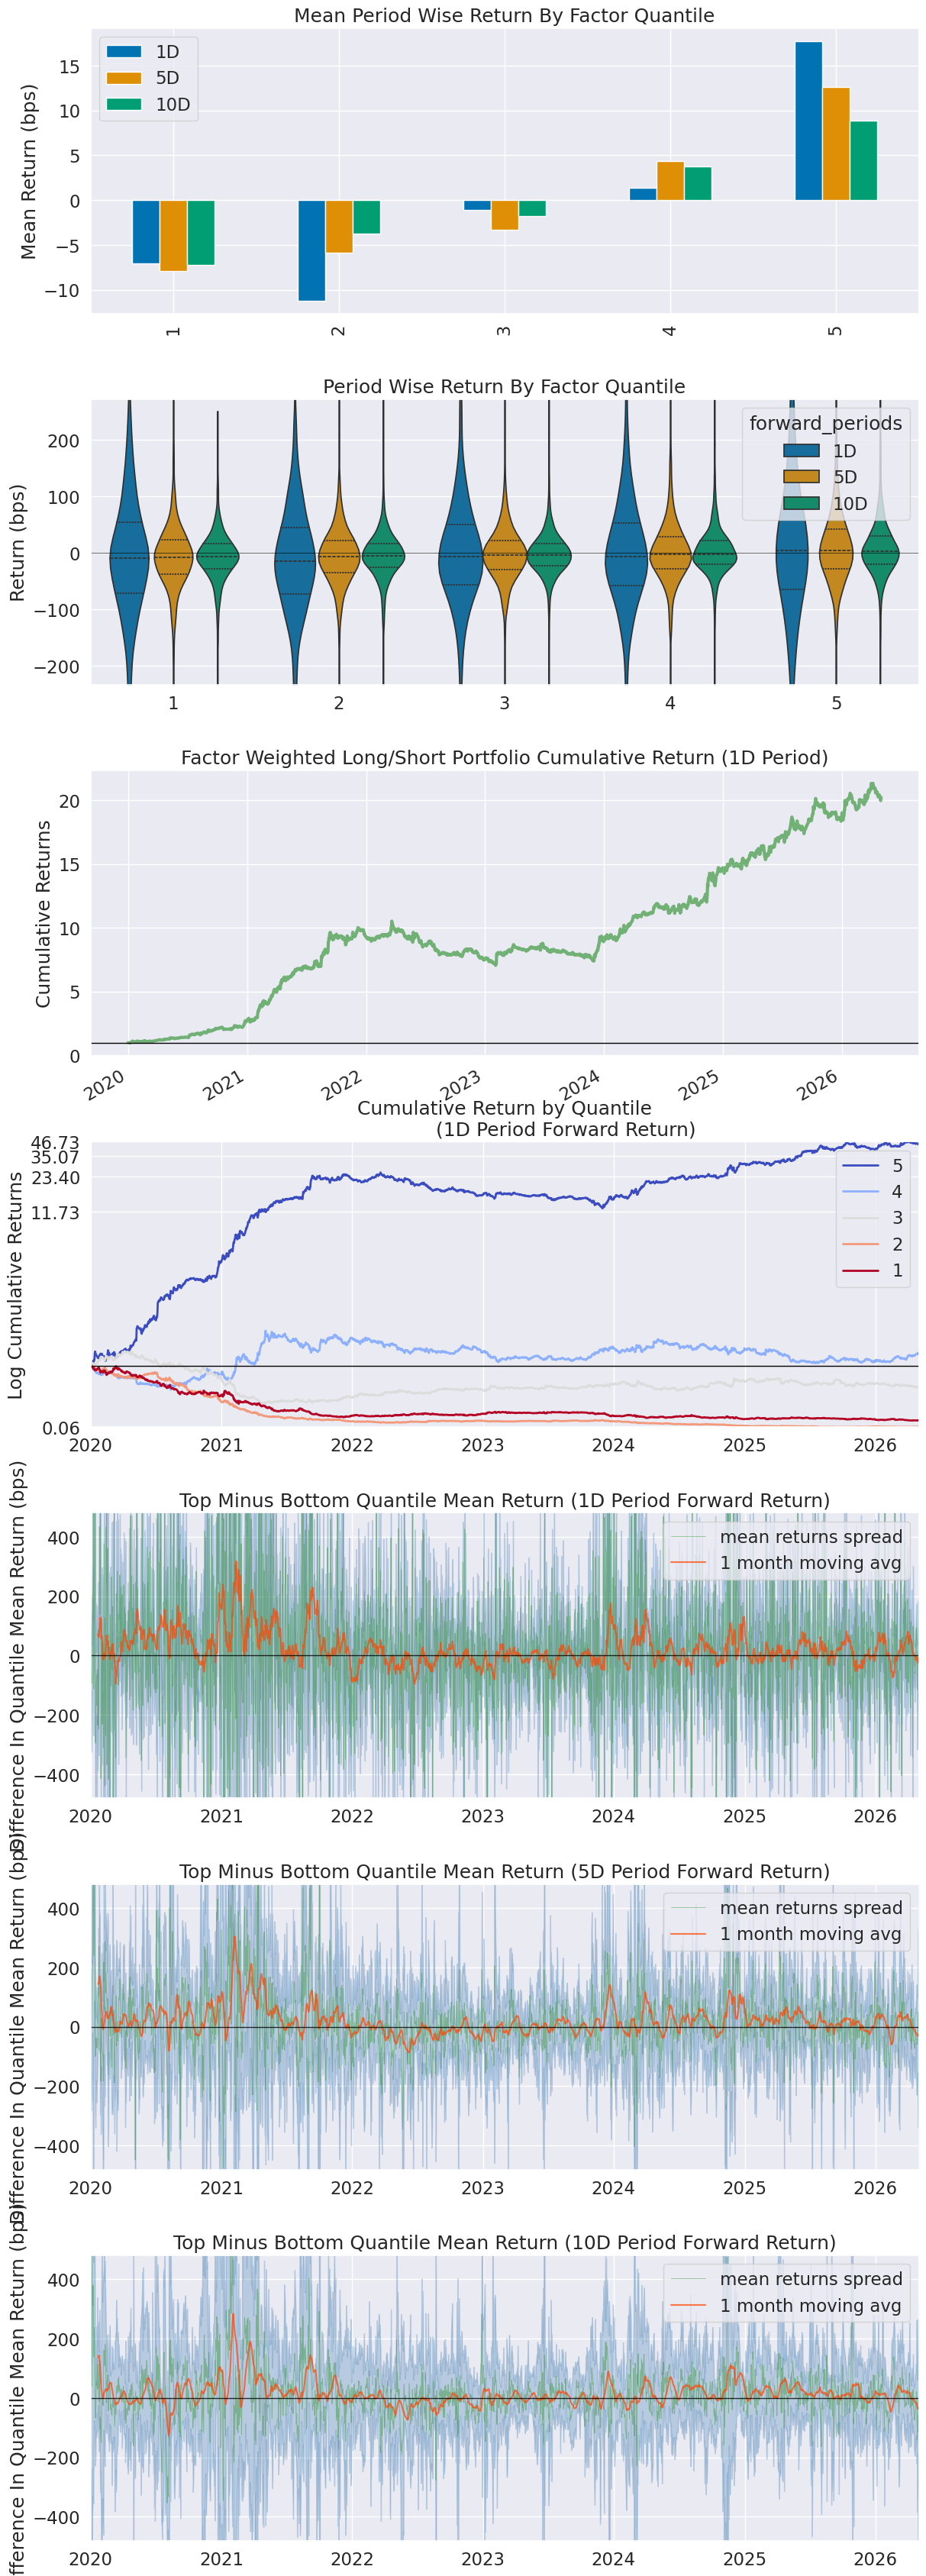

Information Analysis


,1D,5D,10D
IC Mean,0.011,0.024,0.029
IC Std.,0.213,0.204,0.199
Risk-Adjusted IC,0.050,0.118,0.148
t-stat(IC),2.385,5.696,7.118
p-value(IC),0.017,0.000,0.000
IC Skew,-0.119,-0.004,-0.120
IC Kurtosis,-0.151,-0.131,-0.094


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


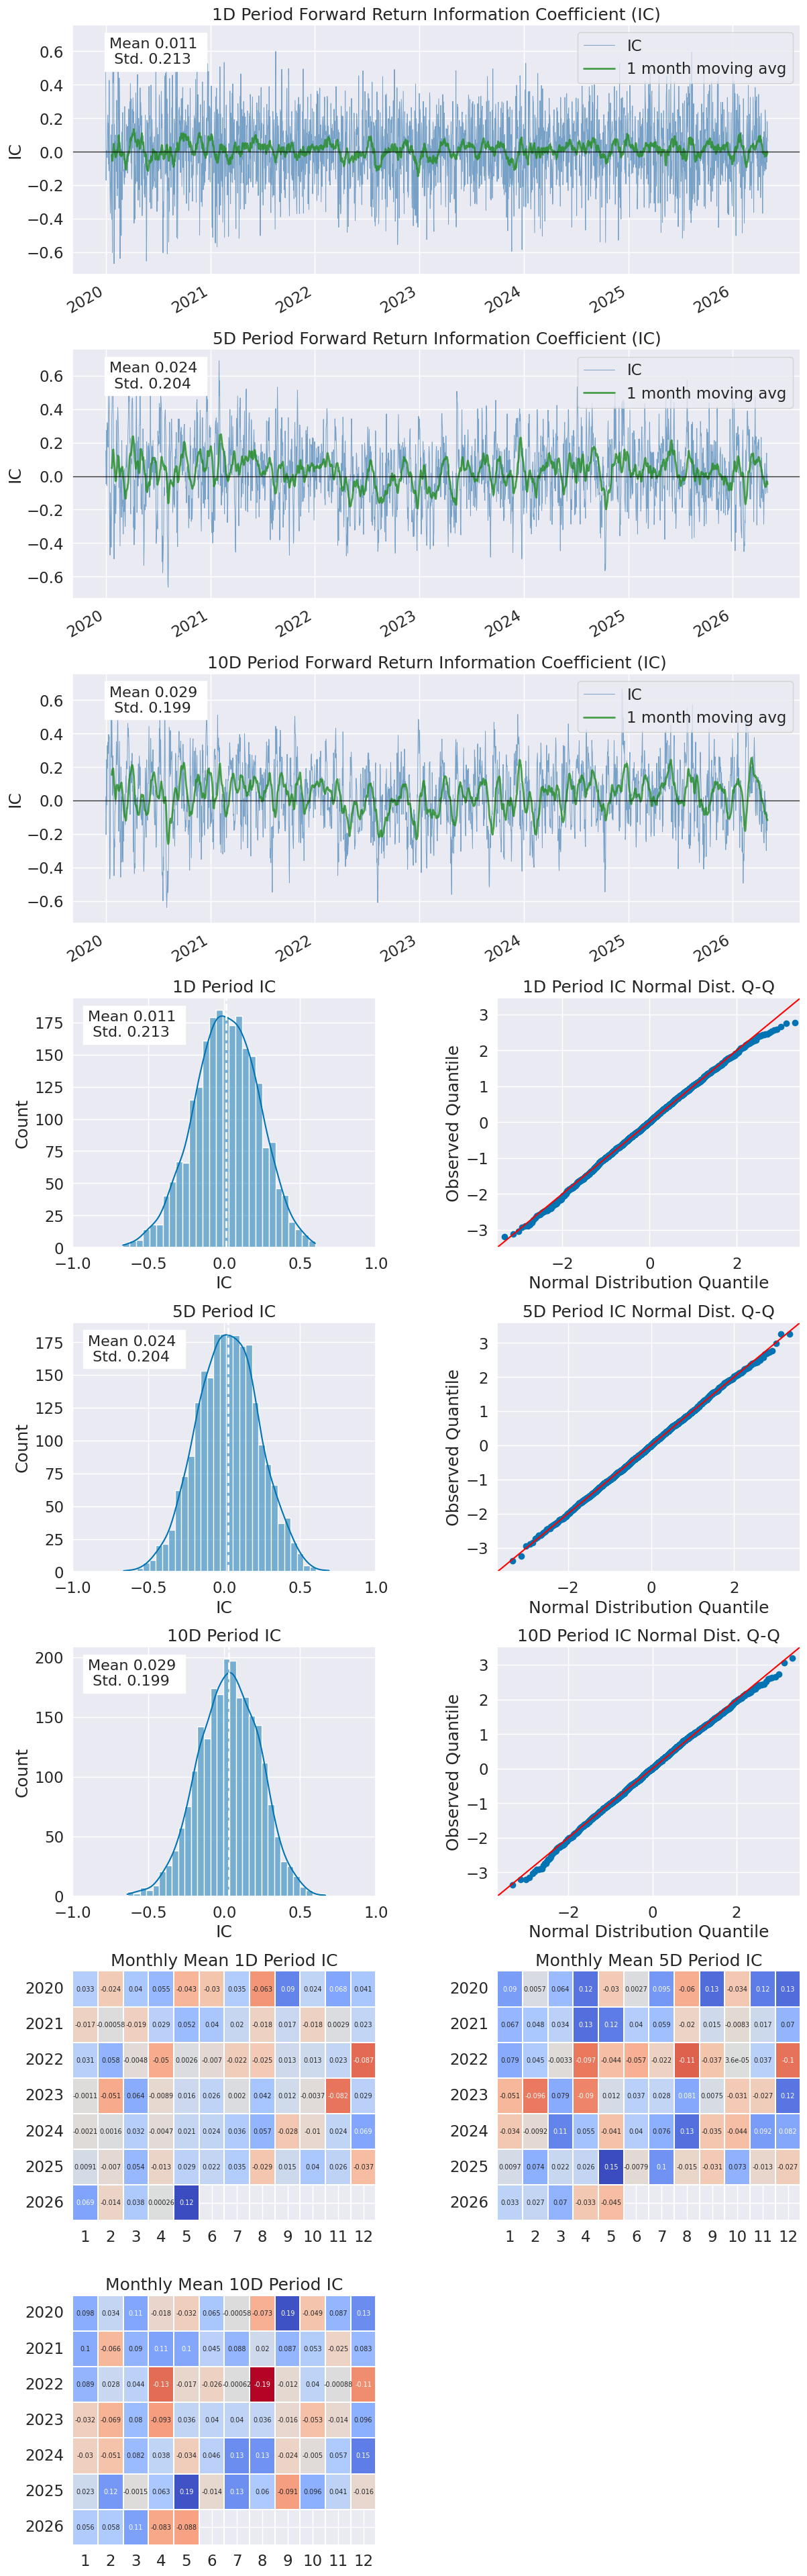

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.394,0.615,0.724
Quantile 2 Mean Turnover,0.540,0.717,0.776
Quantile 3 Mean Turnover,0.553,0.734,0.782
Quantile 4 Mean Turnover,0.493,0.714,0.778
Quantile 5 Mean Turnover,0.259,0.524,0.671


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.795,0.462,0.236


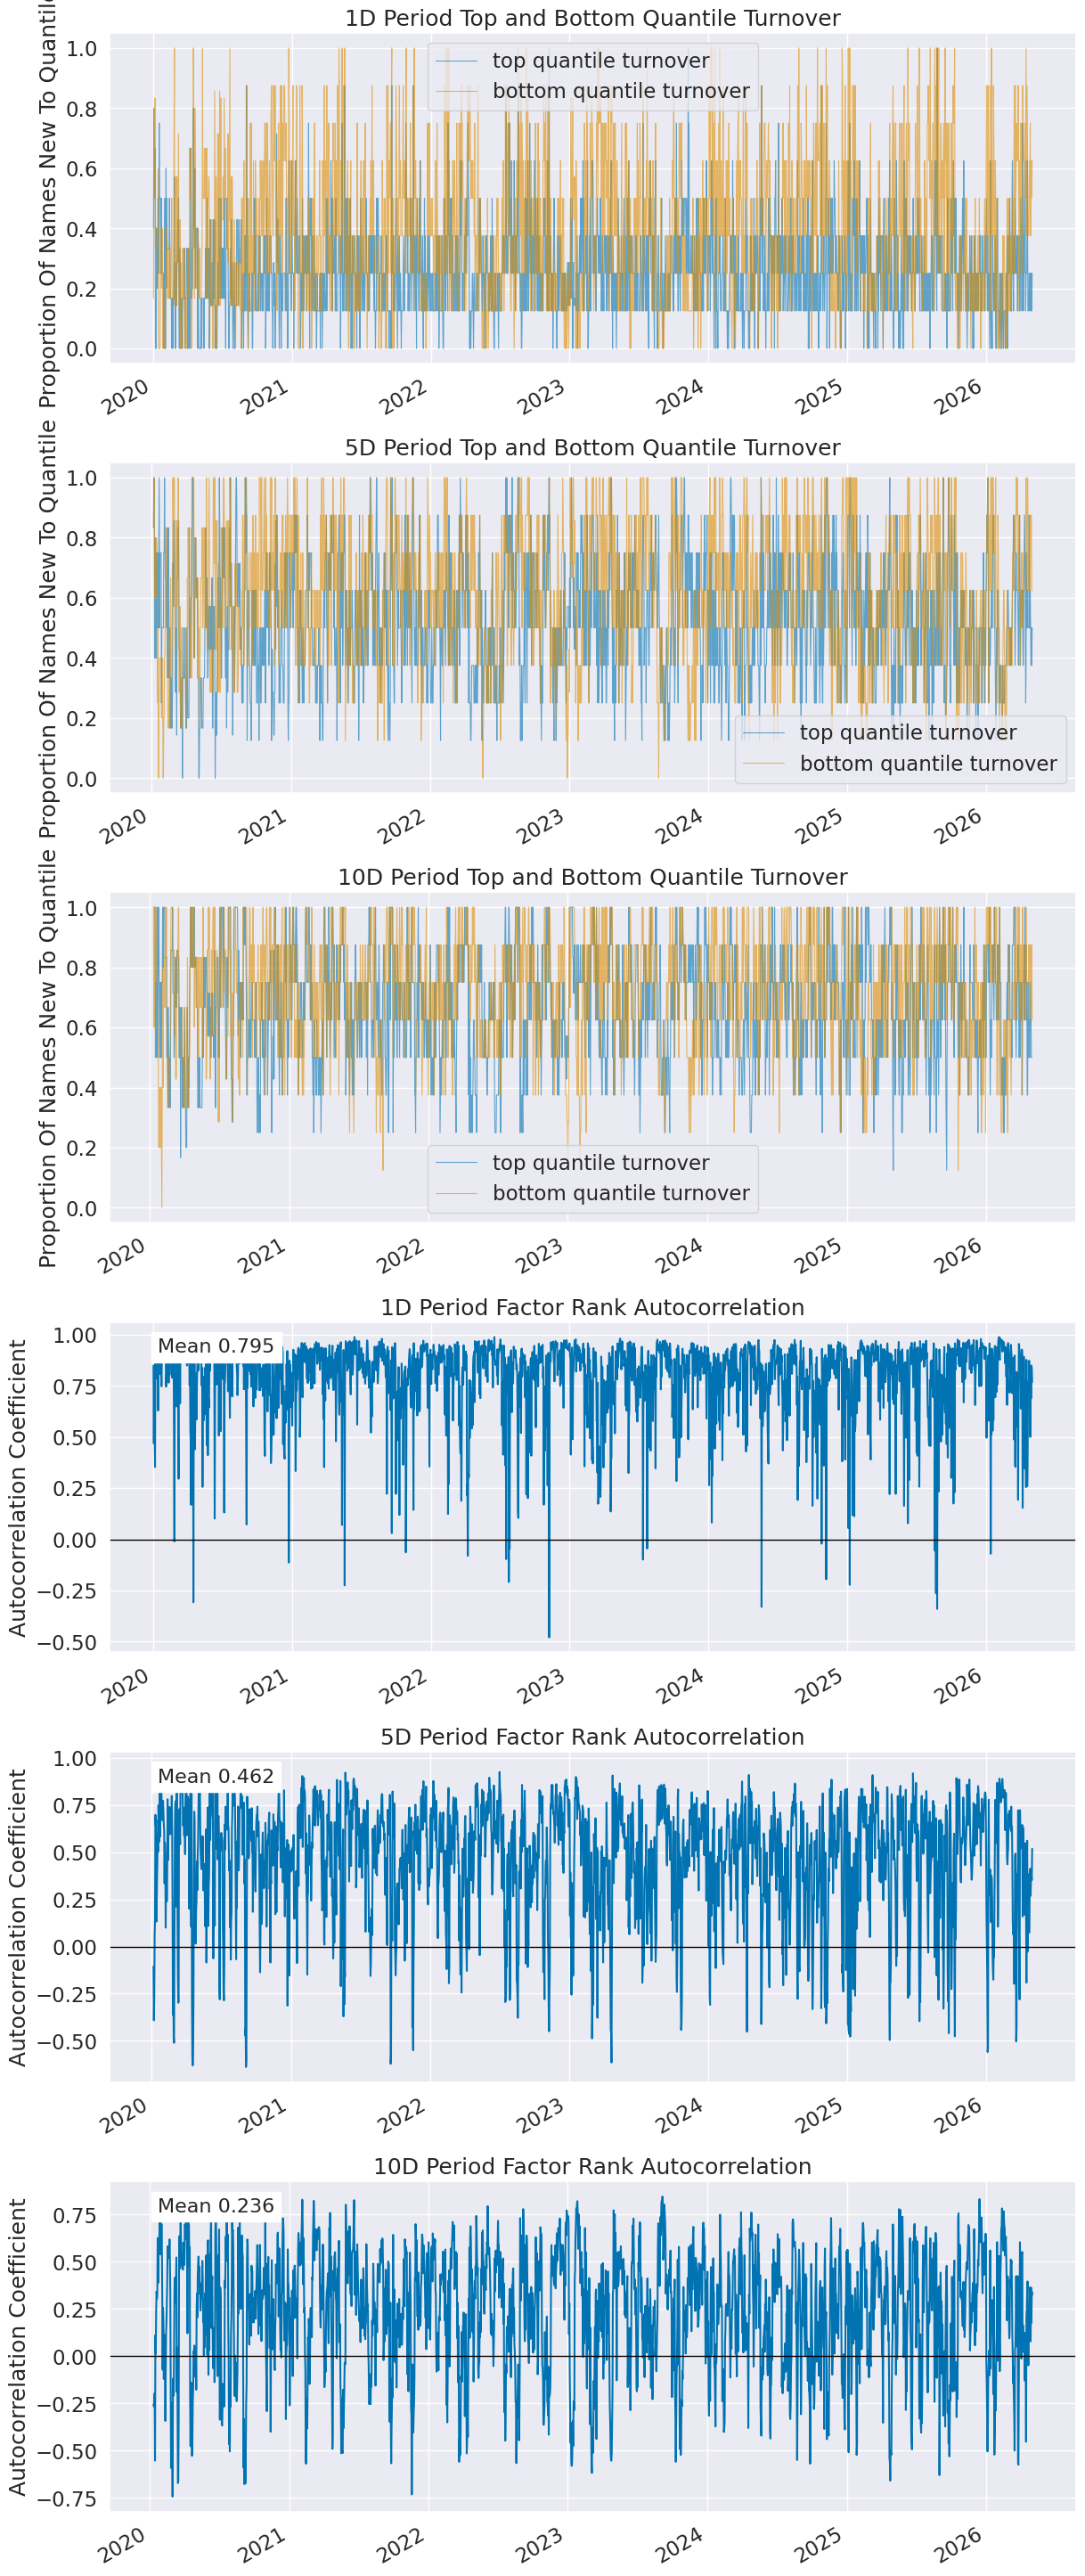

In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "notebooks" / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
for _p in (_root, _root / "notebooks"):
    sys.path.insert(0, str(_p))

from aperiodic import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

APERIODIC_API_KEY = get_env("APERIODIC_API_KEY")

# Instantaneous Volatility -- portfolio instantaneous_volatility.40
portfolio = "instantaneous_volatility"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=APERIODIC_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=APERIODIC_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=APERIODIC_API_KEY)

# Mask the raw factor with the dynamic point-in-time universe (a boolean
# dates x tickers matrix) so AlphaLens scores only the universe we trade,
# not every ticker that was ever tradeable.
universe = get_historical_universe(
    size=universe_size,
    api_key=APERIODIC_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)